In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time as time_package
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.linalg import inv
from scipy.special import logsumexp
from multiprocessing import Pool

from research_code import *
from scipy.fft import fft, fftfreq

In [2]:
import matplotlib as mpl

MM_TO_INCH = 1/25.4

TEXTWIDTH_MM = 164.6
FIG_W = TEXTWIDTH_MM * MM_TO_INCH
FIG_H = 25 * MM_TO_INCH
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.grid.which": "major",
    "axes.axisbelow": True,


    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",

    'lines.linewidth': 0.6,

    "font.family": "serif", 
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7.5,

    "figure.figsize": (FIG_W, FIG_H),

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "mathtext.fontset": "stix",
})

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['axes.unicode_minus'] = False

mpl.rcParams['figure.dpi'] = 150

np.random.seed(1)

data_dir = os.path.join(project_root,'data')
fig_dir = os.path.join(data_dir,'figures')

labels = ['UKF-UI','HKF-ndm','HKFS-ndm','HKF','HKFS',]
colors = ['#181','#a55','#a11','#55a','#11a']
highlight_color = '#fdf2d0a0'
example_name = '3DOF_with_disp'

[3015.10951711 3986.47891361 4707.46942238]
[2846.03652719 3755.36771198 4416.60918792]


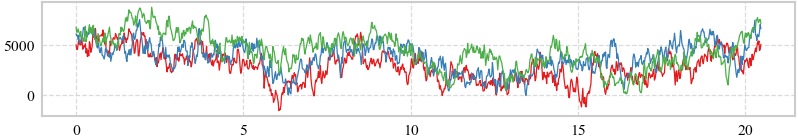

In [3]:
def mean_wind_power_law(z, V_ref, z_ref, alpha):
    z = np.asarray(z, dtype=float)
    return V_ref * (z / z_ref) ** alpha

def kaimal1972_u_psd_one_sided(n_hz, U, z, u_star):
    n = np.asarray(n_hz, dtype=float)
    S = np.zeros_like(n)
    pos = n > 0.0

    f = (n[pos] * z) / max(U, 1e-12)     
    numer = 105.0 * f
    denom = (1.0 + 33.0 * f) ** (5.0 / 3.0)

    S[pos] = (u_star**2 / n[pos]) * (numer / denom)
    return S

def davenport_coherence(n_hz, dz, U_ref, C_u):
    n = np.asarray(n_hz, dtype=float)
    return np.exp(-C_u * n * abs(dz) / max(U_ref, 1e-12))

def generate_correlated_uprime_kaimal1972(
    z_list,
    dt,
    T,
    V_ref,
    z_ref,
    alpha_mean,
    u_star,
    C_u,
    add_jitter= 1e-12
):
    z = np.asarray(z_list, dtype=float)
    m = len(z)

    N_raw = int(np.round(T / dt))
    N = 1 << (N_raw - 1).bit_length()
    T_eff = N * dt
    t = np.arange(N) * dt

    freqs = np.fft.rfftfreq(N, d=dt)
    df = 1.0 / T_eff

    U_mean = mean_wind_power_law(z, V_ref=V_ref, z_ref=z_ref, alpha=alpha_mean)
    U_ref_for_coh = mean_wind_power_law(z_ref, V_ref=V_ref, z_ref=z_ref, alpha=alpha_mean)

    Sii = np.zeros((m, len(freqs)), dtype=float)
    for i in range(m):
        Sii[i, :] = kaimal1972_u_psd_one_sided(freqs, U=U_mean[i], z=z[i], u_star=u_star)

    Xpos = np.zeros((m, len(freqs)), dtype=np.complex128)

    k_max = len(freqs) - 1
    for k in range(1, k_max):
        n = freqs[k]

        Sf = np.zeros((m, m), dtype=float)
        for i in range(m):
            Sf[i, i] = Sii[i, k]

        for i in range(m):
            for j in range(i + 1, m):
                gamma = davenport_coherence(n, dz=z[i] - z[j], U_ref=U_ref_for_coh, C_u=C_u)
                Sf[i, j] = np.sqrt(Sii[i, k] * Sii[j, k]) * gamma
                Sf[j, i] = Sf[i, j]

        Sf = Sf + add_jitter * np.eye(m)

        try:
            Lf = np.linalg.cholesky(Sf)
        except np.linalg.LinAlgError:
            Lf = np.linalg.cholesky(Sf + (10 * add_jitter) * np.eye(m))

        zk = (np.random.standard_normal(m) + 1j * np.random.standard_normal(m)) / np.sqrt(2.0)
        gk = Lf @ zk

        Xpos[:, k] = N * np.sqrt(2.0 * df) * gk

    uprime = np.zeros((m, N), dtype=float)
    for i in range(m):
        uprime[i, :] = np.fft.irfft(Xpos[i, :], n=N)

    return t, U_mean, uprime, freqs

def forces_from_uprime_linearized(U_mean, uprime, A_list, rho=1.25, C_F=1.1):
    U_mean = np.asarray(U_mean, dtype=float)
    A = np.asarray(A_list, dtype=float)
    m, N = uprime.shape
    assert len(U_mean) == m and len(A) == m

    F_mean = 0.5 * rho * C_F * A * (U_mean ** 2)
    F_dyn  = (rho * C_F * A[:, None] * U_mean[:, None]) * uprime
    F_total = F_mean[:, None] + F_dyn
    return F_mean, F_dyn, F_total

z_list = [3.5, 7, 10.5]

t, U_mean, uprime, freqs = generate_correlated_uprime_kaimal1972(
    z_list=z_list,
    dt=0.02,
    T=20.0,
    V_ref=15.0,
    z_ref=10.0,
    alpha_mean=0.20,
    u_star=0.8,   
    C_u=10.0,
)

A_list = [28.0, 28.0, 28.0]
F_mean, F_dyn, F_total = forces_from_uprime_linearized(
    U_mean=U_mean, uprime=uprime, A_list=A_list, rho=1.25, C_F=1.1
)

F_mean_test = np.random.uniform(low=F_mean*0.9, high=F_mean*1.1)
print(F_mean_test)
print(F_mean)

force_value = F_total[:,:1010]
force = Force.assign_by_value(time_point = np.arange(0,20.2,0.02), value=force_value)


plt.plot(t, F_total[0,:])
plt.plot(t, F_total[1,:])
plt.plot(t, F_total[2,:])
plt.show()


In [4]:
mass = [40000]*3
damping = [0.03]*3
stiff = [2e6]*3
comp_mat = np.array(
    [[1,0, 0],
    [-1, 1, 0],
    [0, -1, 1]]
)
parameter = BoucWenParameter(A=[1]*3, alpha=[0.02]*3, n=[1.3]*3, beta=[80]*3, gamma=[20]*3)

system = BoucWenSystem(
    mass = mass,
    damping = damping,
    stiff = stiff, 
    parameter = parameter,
    comp_mat = comp_mat,
    )
print(system.mod_freq)
print(2*np.pi/system.mod_freq)

[12.74162392  8.81747734  3.14692123]
[0.4931228  0.7125831  1.99661347]


In [5]:
time = Time(0, 20, 0.001)
force.interp(time)

response = compute_response(
    system = system,
    force = force,
    time = time,
    ctype = 'Newmark',
    )
time,force,response = slice_data(time,force,response,0.02)

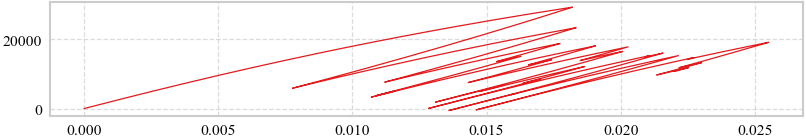

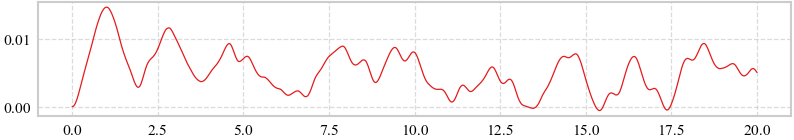

In [6]:
f=0
plt.plot(response.element_disp[f], response.resisting_force[f])
plt.show()
plt.plot(time.value,response.aux[f])
plt.show()

In [7]:
SNR_dB = 15
std_noise = (np.var(response.acc) / (10**(SNR_dB/10)))**0.5
std_noise_disp = (np.var(response.disp[0]) / (10**(SNR_dB/10)))**0.5
print(std_noise, std_noise_disp)
m_number = 50
measurement_set = np.zeros((m_number,system.dim+1,time.length))
measurement_dm_set = np.zeros((m_number,(system.dim+system.element_dim+system.force_dim+1),time.length))
for ii in range(m_number):
    measurement = add_noise(response.acc,std_noise)
    measurement = np.vstack((measurement, add_noise(response.disp[:1],std_noise_disp)))
    measurement_dm = np.vstack((measurement,np.zeros((system.element_dim,time.length)),np.zeros((system.force_dim,time.length))))
    measurement_set[ii] = measurement
    measurement_dm_set[ii] = measurement_dm

0.01189384756959446 0.0007361985387572301


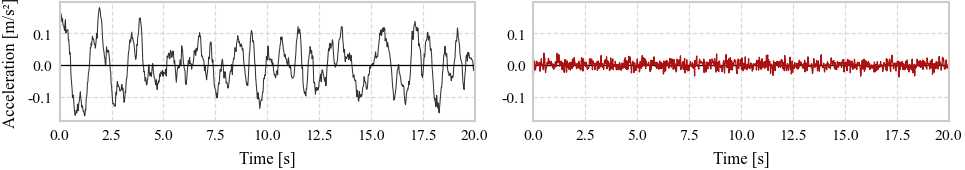

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H*1.2), constrained_layout=True, sharey=True)
ax1.axhline(0, color='k')
ax1.plot(time.value, response.acc[2,:], color='k', alpha=0.8, lw=0.5)
ax1.set_ylabel('Acceleration [m/s²]')
ax1.set_xlim([0,20])
ax1.set_xlabel('Time [s]')

ax2.tick_params(axis='y', left=True, labelleft=True)
ax2.axhline(0, color='k')
ax2.plot(time.value, response.acc[2,:]-measurement[2,:], color=colors[2])
ax2.set_xlim([0,20])
ax2.set_xlabel('Time [s]')

plt.savefig(os.path.join(fig_dir,'measurement_'+example_name+'.pdf'))


In [9]:
def UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, alpha, F_mean, beta=2.0, kappa=0.0):
    state_dim = system.dim * 2 + system.element_dim
    force_dim = system.force_dim

    est_state = np.zeros((state_dim, time.length))
    est_cov = np.zeros((state_dim, state_dim, time.length))
    est_force = np.zeros((force_dim, time.length))

    state = initial_state
    cov = initial_cov
    force = np.zeros(force_dim)
    acc = compute_acc(system, state, force+F_mean)

    n = state_dim
    lam = alpha**2 * (n + kappa) - n
    c = n + lam

    Wm = np.full(2*n + 1, 1.0/(2*c))
    Wc = np.full(2*n + 1, 1.0/(2*c))
    Wm[0] = lam / c
    Wc[0] = lam / c + (1 - alpha**2 + beta)

    for ii in range(time.length):
        evalues, evectors = np.linalg.eig(cov)
        assert (evalues >= 0).all()
        sigma_points = np.zeros((state_dim, 2*state_dim + 1))
        sigma_points[:,0] = state
        L = np.linalg.cholesky(cov)
        for j in range(n):
            sigma_points[:, j+1]     = state + np.sqrt(c) * L[:, j]
            sigma_points[:, j+1+n]   = state - np.sqrt(c) * L[:, j]
        state_pred_points = compute_response_step(system, time, sigma_points, force+F_mean, acc)
        state_pred = np.sum(Wm * state_pred_points, axis=1)
        diff = state_pred_points - state_pred[:, None]
        cov_pred = diff @ np.diag(Wc) @ diff.T + model_cov

        Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
        Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
        Cc = np.vstack((np.hstack((Cc1, Cc2, Cc3)), np.eye(1, state_dim, 0)))
        Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
        Cc4 = np.vstack((Cc4, np.zeros((1, force_dim))))


        force_total = inv(Cc4.T@Cc4)@(Cc4.T)@(measurement[:,ii] - Cc @ state_pred)
        force = force_total - F_mean

        meas_pred_points = np.vstack((compute_acc(system, state_pred_points, force_total[:,None]), state_pred_points[0,:]))
        meas_pred = np.sum(Wm * meas_pred_points, axis=1)
        meas_diff = meas_pred_points - meas_pred[:, None]
        cov_meas = meas_diff @ np.diag(Wc) @ meas_diff.T + measurement_cov

        cross_diff = state_pred_points - state_pred[:, None]
        cross_cov = cross_diff @ np.diag(Wc) @ meas_diff.T
        K = cross_cov @ np.linalg.inv(cov_meas)

        state = state_pred + K @ (measurement[:,ii] - meas_pred)
        cov = cov_pred - K @ cov_meas @ K.T
        
        acc = compute_acc(system, state, force_total)

        est_state[:,ii] = state
        est_cov[:,:,ii] = cov
        est_force[:,ii] = force

    return est_state, est_cov, est_force

def compute_response_step(system, time, state_list, force, acc):
    state_post = np.zeros(state_list.shape)
    acc_post = np.zeros((system.dim, state_list.shape[1]))

    GAMMA = 1/2
    BETA  = 1/4
    dt    = time.interval

    A1 = 1/(BETA*dt**2) * system.mass + (GAMMA/(BETA*dt)) * system.damping
    A2 = 1/(BETA*dt)    * system.mass + (GAMMA/BETA - 1) * system.damping
    A3 = (1/(2*BETA) - 1) * system.mass + system.damping*dt*(GAMMA/(2*BETA) - 1)

    MAX_ITER = 200

    for ii in range(state_list.shape[1]):
        state = state_list[:, ii]

        disp0 = state[0:system.dim].copy()
        aux0  = state[system.dim:system.dim+system.element_dim].copy()
        vel0  = state[system.dim+system.element_dim : system.dim*2+system.element_dim].copy()

        disp = disp0.copy()
        aux  = aux0.copy()

        force_hat = (system.force_influence @ force + A1 @ disp0 + A2 @ vel0 + A3 @ acc)

        for jj in range(MAX_ITER):
            
            element_disp = system.comp_mat @ disp
            resisting_force = (system.alpha * system.element_stiff * element_disp + (1 - system.alpha) * system.element_stiff * aux)
            
            residual_force = force_hat - system.comp_mat.T @ resisting_force - A1 @ disp

            if (np.all(residual_force**2 < 1e-18) or np.all(residual_force**2 / np.maximum(np.max(np.abs(force_hat)), 1e-10)**2 < 1e-18)):
                break

            if system.model == 'BoucWen':
                vel_e = system.comp_mat @ vel0
                g = (system.A - np.abs(aux)**system.n * (system.gamma + system.beta * np.sign(aux * vel_e)))
                k_t_elem = (system.alpha * system.element_stiff + (1 - system.alpha) * system.element_stiff * g)
                K_tangent = system.comp_mat.T @ np.diag(k_t_elem) @ system.comp_mat
                tangent_stiff_hat = K_tangent + A1
            else:
                tangent_stiff_hat = system.stiff + A1

            delta_disp = np.linalg.solve(tangent_stiff_hat, residual_force)

            disp_new = disp + delta_disp

            if system.model == 'BoucWen':
                element_disp_new = system.comp_mat @ disp_new
                delta_element_disp = element_disp_new - element_disp
                aux = aux + delta_element_disp * g

            disp = disp_new

        if jj == MAX_ITER - 1 and np.any(np.abs(residual_force) >= 1e-12):
            print(residual_force, force_hat)
            print('Newton-Raphson did not converge')

        vel = (GAMMA/(BETA*dt))*(disp - disp0) + (1 - GAMMA/BETA)*vel0 + dt*(1 - GAMMA/(2*BETA))*acc

        state_post[:, ii] = np.concatenate((disp, aux, vel))

    return state_post

def compute_acc(system, state, force):
    Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
    Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
    Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
    Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
    Cc = np.hstack((Cc1, Cc2, Cc3))
    return Cc@state + Cc4@force

In [10]:
UKFUI_results = []
time_UKF = np.zeros(m_number)
for ii in range(m_number):
    measurement = measurement_set[ii]
    initial_state = np.zeros(system.dim*2+system.element_dim)
    initial_cov = np.eye(system.dim*2+system.element_dim)*1e-10
    model_cov = np.diag([1e-10]*(system.dim*2+system.element_dim))
    measurement_cov = np.diag([std_noise**2]*system.dim + [std_noise_disp**2])
    scale=1
    start_time = time_package.perf_counter()
    est_state, est_cov, est_force = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, scale,F_mean_test)
    duration = time_package.perf_counter() - start_time
    if duration < 0:
        print(f"Warning: Negative time detected at index {ii}: {duration}")
    time_UKF[ii] = duration
    UKFUI_results.append((est_state, est_cov, est_force))
    print(f"Progress: {ii+1}/{m_number}", end='\r')

In [11]:
class HysteresisSSM_3dof(HysteresisSSM):
    def __init__(self, system, time, F_mean, mtype='3dof'):
        super().__init__(system, time, mtype)
        self.Fa = np.zeros(self.state_size)
        self.F_mean = F_mean
        self.Ed = self.Dd@self.F_mean
        self.measurement_size = self.Dd.shape[0]
        
    def _update_SSM(self,state):
        element_vel = np.atleast_1d(self.system.comp_mat@state[self.system.dim+self.system.element_dim:2*self.system.dim+self.system.element_dim])
        aux = np.atleast_1d(state[self.system.dim:self.system.dim+self.system.element_dim])

        if self.system.model == 'Bilinear':
            Ac23 = []
            for ii in range(self.system.element_dim):
                if aux[ii] > self.system.fy[ii]/self.system.element_stiff[ii] and element_vel[ii]>0:
                    Ac23.append(0)
                elif aux[ii] < -self.system.fy[ii]/self.system.element_stiff[ii] and element_vel[ii]<0:
                    Ac23.append(0)
                else:
                    Ac23.append(1)
        elif self.system.model == 'BoucWen':
            Ac22 = -self.system.n*element_vel*abs(aux)**(self.system.n-1)*(self.system.gamma*np.sign(aux)+self.system.beta*np.sign(element_vel))
            Ac23 = self.system.A - abs(aux)**self.system.n*(self.system.gamma+self.system.beta*np.sign(aux*element_vel))
            self.Ac[self.system.dim:self.system.dim+self.system.element_dim,self.system.dim:self.system.dim+self.system.element_dim] = np.diag(Ac22)

            self.Fac = np.zeros(self.state_size)
            self.Fac[self.system.dim:self.system.dim+self.system.element_dim] = self.system.n*element_vel*abs(aux)**(self.system.n-1)*(self.system.gamma*np.sign(aux)+self.system.beta*np.sign(element_vel))*aux
            self.Fac[self.system.dim+self.system.element_dim:self.system.dim*2+self.system.element_dim] = inv(self.system.mass) @ self.system.force_influence @ self.F_mean
        Ac23 = np.diag(Ac23) @ self.system.comp_mat
        self.Ac[self.system.dim:self.system.dim+self.system.element_dim,self.system.dim+self.system.element_dim:self.system.dim*2+self.system.element_dim] = Ac23
        self.Aac = np.block([[self.Ac, self.Bc],[self.zeros_FG, self.zeros_FL, self.zeros_FG, self.zeros_FF]])
        M = np.hstack((self.Aac, self.Fac.reshape(-1,1)))
        M = np.vstack((M, np.zeros((1,self.state_size+1))))
        eM = expm(M*self.time.interval)
        Aa = eM[0:self.state_size,0:self.state_size]
        Fa = eM[0:self.state_size,-1]
        return Aa, Fa, self.Aac
        

    def _measurement_update(self, state_tmp, cov_tmp, y):
        kalman_gain = cov_tmp @ (self.Ga.T) @ inv(self.Ga @ cov_tmp @ (self.Ga.T) + self.cov_measurement)
        state = state_tmp + kalman_gain @ (y - self.Ga @ state_tmp - self.Ed)
        cov = (np.eye(self.state_size) - kalman_gain @ self.Ga) @ cov_tmp
        return state, cov
    
    def gen_result(self, state):
        response_est = Response(self.system.dim, self.time.length, self.time)
        if self.system.model == 'Linear':
            force_est = Force.assign_by_value(self.time.value, self.kf[2*self.system.dim:,:])
            response_est.disp = state[0:self.system.dim,:]
            response_est.vel = state[self.system.dim:2*self.system.dim,:]
            response_est.acc = (self.Ac @ state[0:self.system.dim*2,:] + self.Bc @ state[self.system.dim*2:,:])[self.system.dim:2*self.system.dim,:]
        else:
            force_est = Force.assign_by_value(self.time.value, state[-self.system.force_dim:,:])
            response_est.disp = state[0:self.system.dim,:]
            response_est.aux = state[self.system.dim:self.system.dim+self.system.element_dim,:]
            response_est.vel = state[self.system.dim+self.system.element_dim:2*self.system.dim+self.system.element_dim,:]
            Ac31 = np.atleast_2d(-inv(self.system.mass)@self.system.comp_mat.T@np.diag(self.system.alpha*self.system.element_stiff)@self.system.comp_mat)
            Ac32 = np.atleast_2d(-inv(self.system.mass)@self.system.comp_mat.T@np.diag((1-self.system.alpha)*self.system.element_stiff))
            Ac33 = np.atleast_2d(-inv(self.system.mass)@self.system.damping)
            response_est.acc = Ac31@response_est.disp + Ac32@response_est.aux + Ac33@response_est.vel+ inv(self.system.mass)@self.system.force_influence@force_est.value + inv(self.system.mass)@self.system.force_influence@self.F_mean.reshape([-1,1])
        return response_est, force_est

class HysteresisDMSSM_3dof(HysteresisSSM_3dof):
    def __init__(self, system, time, F_mean, mtype='3dof'):
        super().__init__(system, time, F_mean, mtype=mtype)
        self.Ga = np.block([[self.Ga], [self.zeros_LG, self.eyes_LL,  self.zeros_LG, self.zeros_FL.T]])
        self.Ga = np.block([[self.Ga], [self.zeros_FG, self.zeros_FL, self.zeros_FG, np.eye(self.system.force_dim)]])
        self.measurement_size = self.system.dim+self.system.element_dim + self.system.force_dim +1
        self.Ed = np.zeros(self.measurement_size)
        self.Ed[:self.Dd.shape[0]] = self.Dd @ self.F_mean

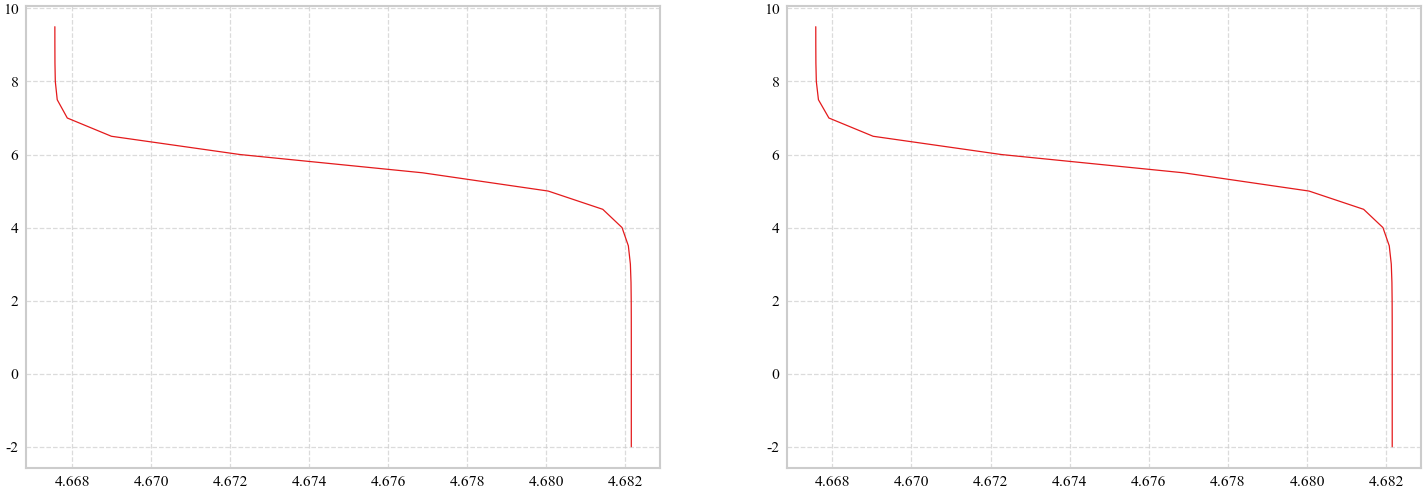

In [12]:
ssm = HysteresisSSM_3dof(system, time, F_mean_test)
ssm_dm = HysteresisDMSSM_3dof(system, time, F_mean_test)

cov_model = [1e-6]*(2*system.dim+system.element_dim)

cov_measurement = np.diag([std_noise**2]*system.dim + [std_noise_disp**2])
cov_measurement_dm = np.diag([std_noise**2]*system.dim + [std_noise_disp**2]+[10**20.0]*system.element_dim+[10**10]*system.force_dim)
cov_force = [10**0]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force)

force_cov_list1 = np.arange(-2,10,0.5)
force_cov_list2 = np.arange(-2,10,0.5)

err = ssm.draw_Lcurve(measurement = measurement, initial_state_cov = np.eye(ssm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 16)
err_dm = ssm_dm.draw_Lcurve(measurement = measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10, force_cov_list=force_cov_list2, num_cores = 16)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(err[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm[:,0], force_cov_list2)
plt.show()

In [13]:
ssm = HysteresisSSM_3dof(system, time, F_mean_test)
ssm_dm = HysteresisDMSSM_3dof(system, time, F_mean_test)

cov_force = [10**7.5]*system.force_dim
cov_force5 = [10**7.5]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force5)

HKFS_results = []
HKFS_ndm_results = []
time_HKF_ndm = np.zeros(m_number)
time_HKF = np.zeros(m_number)
for ii in range(m_number):
    measurement = measurement_set[ii]
    measurement_dm = measurement_dm_set[ii]
    start_time = time_package.perf_counter()
    response_kf, force_kf, response_rts, force_rts = ssm.kfrts(measurement, initial_state_cov = np.eye(ssm.state_size)*10**-10)
    duration = time_package.perf_counter() - start_time
    if duration < 0:
        print(f"Warning: Negative time detected at index {ii}: {duration}")
    time_HKF_ndm[ii] =duration
    start_time = time_package.perf_counter()
    response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = ssm_dm.kfrts(measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10)
    duration = time_package.perf_counter() - start_time
    if duration < 0:
        print(f"Warning: Negative time detected at index {ii}: {duration}")
    time_HKF[ii] = duration
    HKFS_ndm_results.append((response_kf, force_kf, response_rts, force_rts))
    HKFS_results.append((response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm))
    print(f"Progress: {ii+1}/{m_number}", end='\r')

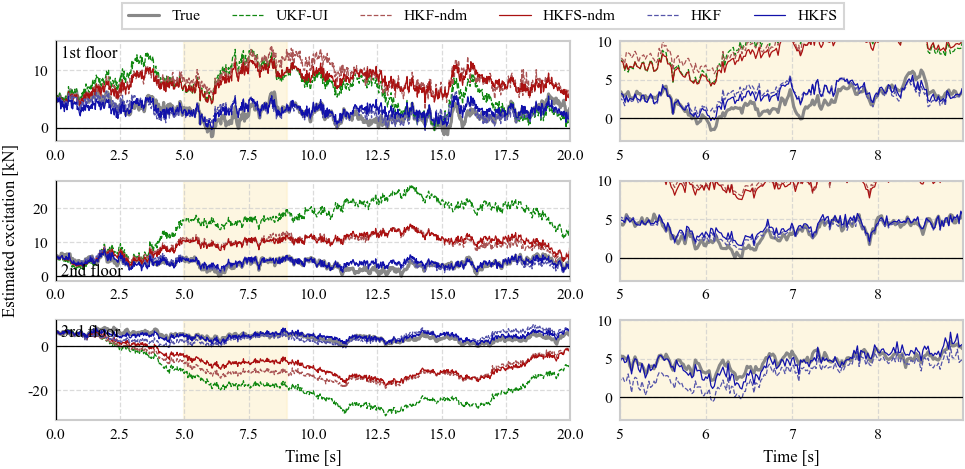

In [14]:
s = 250
e = 450
highlight_color = '#fdf2d0a0'
scale = 1/1000

est_state, est_cov, est_force = UKFUI_results[-1]
response_kf, force_kf, response_rts, force_rts = HKFS_ndm_results[-1]
response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = HKFS_results[-1]

t_start = float(time.value[s])
t_end   = float(time.value[e-1])

num_col = 3

fig = plt.figure(figsize=(FIG_W, num_col*FIG_H), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[1.5, 1.0])

axes = []
linestyles = ['--','--','-','--','-'] 
floors = ['1st floor', '2nd floor', '3rd floor']

for i in range(3):
    ax_full = fig.add_subplot(gs[i, 0])
    ax_zoom = fig.add_subplot(gs[i, 1])
    axes.append((ax_full, ax_zoom))

rows = [
    dict(name="First floor",
         true_full=F_total[0, :1001],
         pred_list_full=[
             est_force[0, :] + F_mean_test[0],
             force_kf.value[0, :] + F_mean_test[0],
             force_rts.value[0, :] + F_mean_test[0],
             force_kf_dm.value[0, :] + F_mean_test[0],
             force_rts_dm.value[0, :] + F_mean_test[0],
         ],
         true_zoom=F_total[0, s:e],
         pred_list_zoom=[
             est_force[0, s:e] + F_mean_test[0],
             force_kf.value[0, s:e] + F_mean_test[0],
             force_rts.value[0, s:e] + F_mean_test[0],
             force_kf_dm.value[0, s:e] + F_mean_test[0],
             force_rts_dm.value[0, s:e] + F_mean_test[0],
         ],
         ylim_zoom=[-3, 10]),
    dict(name="Second floor",
         true_full=F_total[1, :1001],
         pred_list_full=[
             est_force[1, :] + F_mean_test[1],
             force_kf.value[1, :] + F_mean_test[1],
             force_rts.value[1, :] + F_mean_test[1],
             force_kf_dm.value[1, :] + F_mean_test[1],
             force_rts_dm.value[1, :] + F_mean_test[1],
         ],
         true_zoom=F_total[1, s:e],
         pred_list_zoom=[
             est_force[1, s:e] + F_mean_test[1],
             force_kf.value[1, s:e] + F_mean_test[1],
             force_rts.value[1, s:e] + F_mean_test[1],
             force_kf_dm.value[1, s:e] + F_mean_test[1],
             force_rts_dm.value[1, s:e] + F_mean_test[1],
         ],
         ylim_zoom=[-3, 10]),
    dict(name="Third floor",
         true_full=F_total[2, :1001],
         pred_list_full=[
             est_force[2, :] + F_mean_test[2],
             force_kf.value[2, :] + F_mean_test[2],
             force_rts.value[2, :] + F_mean_test[2],
             force_kf_dm.value[2, :] + F_mean_test[2],
             force_rts_dm.value[2, :] + F_mean_test[2],
         ],
         true_zoom=F_total[2, s:e],
         pred_list_zoom=[
             est_force[2, s:e] + F_mean_test[2],
             force_kf.value[2, s:e] + F_mean_test[2],
             force_rts.value[2, s:e] + F_mean_test[2],
             force_kf_dm.value[2, s:e] + F_mean_test[2],
             force_rts_dm.value[2, s:e] + F_mean_test[2],
         ],
         ylim_zoom=[-3, 10]),
]

for i, row in enumerate(rows):
    ax_full, ax_zoom = axes[i]

    for ax in (ax_full, ax_zoom):
        ax.axhline(0, color='k', lw=0.6, zorder=3)
        ax.axvline(0, color='k', lw=0.6, zorder=3)

    ax_full.axvspan(t_start, t_end, color=highlight_color, zorder=0)

    ax_full.plot(time.value[:1001], row["true_full"]*scale, color='#888', label='True', lw=1.5)
    for yhat, lab, col, ls in zip(row["pred_list_full"], labels, colors, linestyles):
        ax_full.plot(time.value[:1001], yhat[:1001]*scale, label=lab, color=col, ls=ls)
    if i == 1:
        ax_full.text(0.01, 0.05, floors[i], transform=ax_full.transAxes)
    else:
        ax_full.text(0.01, 0.95, floors[i], transform=ax_full.transAxes, va='top')

    ax_full.set_xlim(0, 20)

    ax_zoom.set_facecolor(highlight_color)
    ax_zoom.plot(time.value[s:e], row["true_zoom"]*scale, color='#888', lw=1.5)
    for yhat, lab, col, ls in zip(row["pred_list_zoom"], labels, colors, linestyles):
        ax_zoom.plot(time.value[s:e], yhat*scale, color=col, ls=ls)

    ax_zoom.set_xlim(t_start, t_end)
    if row["ylim_zoom"] is not None:
        ax_zoom.set_ylim(*row["ylim_zoom"])

    if i == 1:
        ax_full.set_ylabel("Estimated excitation [kN]")

axes[2][0].set_xlabel("Time [s]")
axes[2][1].set_xlabel("Time [s]")

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, leg_labels,
    loc="center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=True,
    fancybox=False,
    ncol=7
)

fig.align_ylabels([ax[0] for ax in axes])

outpath = os.path.join(fig_dir, f"estimation_force_{example_name}.pdf")
fig.savefig(outpath)
plt.show()

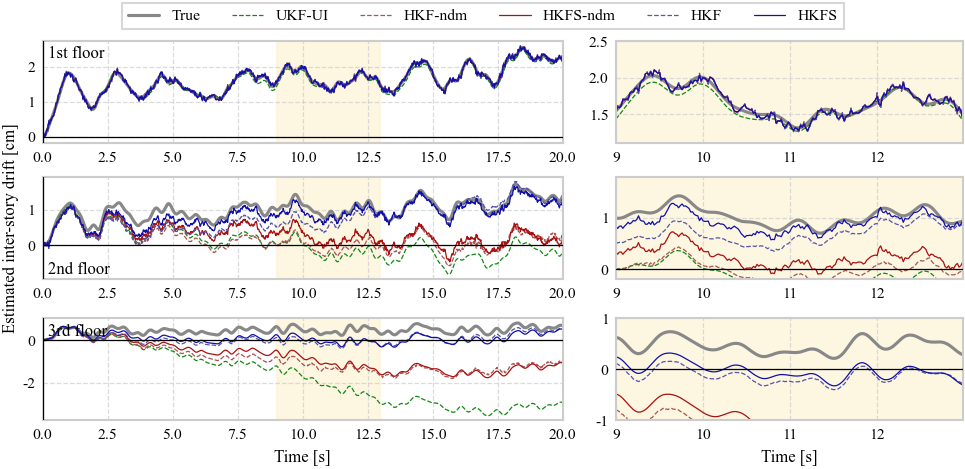

In [15]:
s = 450
e = 650
highlight_color = '#fdf2d0a0'
scale = 100

t_start = float(time.value[s])
t_end   = float(time.value[e-1])

num_col = 3

fig = plt.figure(figsize=(FIG_W, num_col*FIG_H), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[1.5, 1.0])

axes = []

for i in range(3):
    ax_full = fig.add_subplot(gs[i, 0])
    ax_zoom = fig.add_subplot(gs[i, 1])
    axes.append((ax_full, ax_zoom))

rows = [
    dict(name="First floor",
         true_full=response.element_disp[0, :],      pred_list_full=[(system.comp_mat@est_state[:3])[0,:], (system.comp_mat@response_kf.disp)[0,:], (system.comp_mat@response_rts.disp)[0,:], (system.comp_mat@response_kf_dm.disp)[0,:], (system.comp_mat@response_rts_dm.disp)[0,:]],
         true_zoom=response.element_disp[0, s:e],    pred_list_zoom=[(system.comp_mat@est_state[:3])[0,s:e], (system.comp_mat@response_kf.disp)[0,s:e], (system.comp_mat@response_rts.disp)[0,s:e], (system.comp_mat@response_kf_dm.disp)[0,s:e], (system.comp_mat@response_rts_dm.disp)[0,s:e]],
         ylim_zoom=[1.1,2.5]),
    dict(name="Second floor",
         true_full=response.element_disp[1, :],      pred_list_full=[(system.comp_mat@est_state[:3])[1,:], (system.comp_mat@response_kf.disp)[1,:], (system.comp_mat@response_rts.disp)[1,:], (system.comp_mat@response_kf_dm.disp)[1,:], (system.comp_mat@response_rts_dm.disp)[1,:]],
         true_zoom=response.element_disp[1, s:e],    pred_list_zoom=[(system.comp_mat@est_state[:3])[1,s:e], (system.comp_mat@response_kf.disp)[1,s:e], (system.comp_mat@response_rts.disp)[1,s:e], (system.comp_mat@response_kf_dm.disp)[1,s:e], (system.comp_mat@response_rts_dm.disp)[1,s:e]],
         ylim_zoom=[-0.2,1.8]),
    dict(name="Third floor",
         true_full=response.element_disp[2, :],      pred_list_full=[(system.comp_mat@est_state[:3])[2,:], (system.comp_mat@response_kf.disp)[2,:], (system.comp_mat@response_rts.disp)[2,:], (system.comp_mat@response_kf_dm.disp)[2,:], (system.comp_mat@response_rts_dm.disp)[2,:]],
         true_zoom=response.element_disp[2, s:e],    pred_list_zoom=[(system.comp_mat@est_state[:3])[2,s:e], (system.comp_mat@response_kf.disp)[2,s:e], (system.comp_mat@response_rts.disp)[2,s:e], (system.comp_mat@response_kf_dm.disp)[2,s:e], (system.comp_mat@response_rts_dm.disp)[2,s:e]],
         ylim_zoom=[-1,1]),
]

for i, row in enumerate(rows):
    ax_full, ax_zoom = axes[i]

    for ax in (ax_full, ax_zoom):
        ax.axhline(0, color='k', lw=0.6, zorder=3)
        ax.axvline(0, color='k', lw=0.6, zorder=3)

    ax_full.axvspan(t_start, t_end, color=highlight_color, zorder=0)

    ax_full.plot(time.value[:1001], row["true_full"]*scale, color='#888', label='True', lw=1.5)
    for yhat, lab, col, ls in zip(row["pred_list_full"], labels, colors, linestyles):
        ax_full.plot(time.value[:1001], yhat[:1001]*scale, label=lab, color=col, ls=ls)

    ax_full.set_xlim(0, 20)

    if i == 1:
        ax_full.text(0.01, 0.05, floors[i], transform=ax_full.transAxes)
    else:
        ax_full.text(0.01, 0.95, floors[i], transform=ax_full.transAxes, va='top')

    ax_zoom.set_facecolor(highlight_color)
    ax_zoom.plot(time.value[s:e], row["true_zoom"]*scale, color='#888', lw=1.5)
    for yhat, lab, col, ls in zip(row["pred_list_zoom"], labels, colors, linestyles):
        ax_zoom.plot(time.value[s:e], yhat*scale, color=col, ls=ls)

    ax_zoom.set_xlim(t_start, t_end)
    if row["ylim_zoom"] is not None:
        ax_zoom.set_ylim(*row["ylim_zoom"])

    if i == 1:
        ax_full.set_ylabel("Estimated inter-story drift [cm]")

axes[2][0].set_xlabel("Time [s]")
axes[2][1].set_xlabel("Time [s]")

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, leg_labels,
    loc="center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=True,
    fancybox=False,
    ncol=7
)

outpath = os.path.join(fig_dir, f"estimation_drift_{example_name}.pdf")
fig.savefig(outpath)
plt.show()

In [16]:
def rmse(true, pred):
    return np.sqrt(np.mean((true-pred)**2,axis=1))

rmse_force_UKFUI = np.zeros((m_number, system.force_dim))
rmse_force_HKF_ndm = np.zeros((m_number, system.force_dim))
rmse_force_HKF = np.zeros((m_number, system.force_dim))
rmse_force_HKFS_ndm = np.zeros((m_number, system.force_dim))
rmse_force_HKFS = np.zeros((m_number, system.force_dim))

for ii in range(m_number):
    est_state, est_cov, est_force = UKFUI_results[ii]
    response_kf, force_kf, response_rts, force_rts = HKFS_ndm_results[ii]
    response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = HKFS_results[ii]
    
    rmse_force_UKFUI[ii,:] = rmse(F_total[:,:1001], est_force+F_mean_test.reshape(-1,1))
    rmse_force_HKF_ndm[ii,:] = rmse(F_total[:,:1001], force_kf.value+F_mean_test.reshape(-1,1))
    rmse_force_HKF[ii,:] = rmse(F_total[:,:1001], force_kf_dm.value+F_mean_test.reshape(-1,1))
    rmse_force_HKFS_ndm[ii,:] = rmse(F_total[:,:1001], force_rts.value+F_mean_test.reshape(-1,1))
    rmse_force_HKFS[ii,:] = rmse(F_total[:,:1001], force_rts_dm.value+F_mean_test.reshape(-1,1))

rmse_drift_UKFUI = np.zeros((m_number, system.dim))
rmse_drift_HKF_ndm = np.zeros((m_number, system.dim))
rmse_drift_HKF = np.zeros((m_number, system.dim))
rmse_drift_HKFS_ndm = np.zeros((m_number, system.dim))
rmse_drift_HKFS = np.zeros((m_number, system.dim))
for ii in range(m_number):
    est_state, est_cov, est_force = UKFUI_results[ii]
    response_kf, force_kf, response_rts, force_rts = HKFS_ndm_results[ii]
    response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = HKFS_results[ii]
    
    rmse_drift_UKFUI[ii,:] = rmse(response.element_disp, (system.comp_mat@est_state[0:system.dim]))
    rmse_drift_HKF_ndm[ii,:] = rmse(response.element_disp, (system.comp_mat@response_kf.disp))
    rmse_drift_HKF[ii,:] = rmse(response.element_disp, (system.comp_mat@response_kf_dm.disp))
    rmse_drift_HKFS_ndm[ii,:] = rmse(response.element_disp, (system.comp_mat@response_rts.disp))
    rmse_drift_HKFS[ii,:] = rmse(response.element_disp, (system.comp_mat@response_rts_dm.disp))

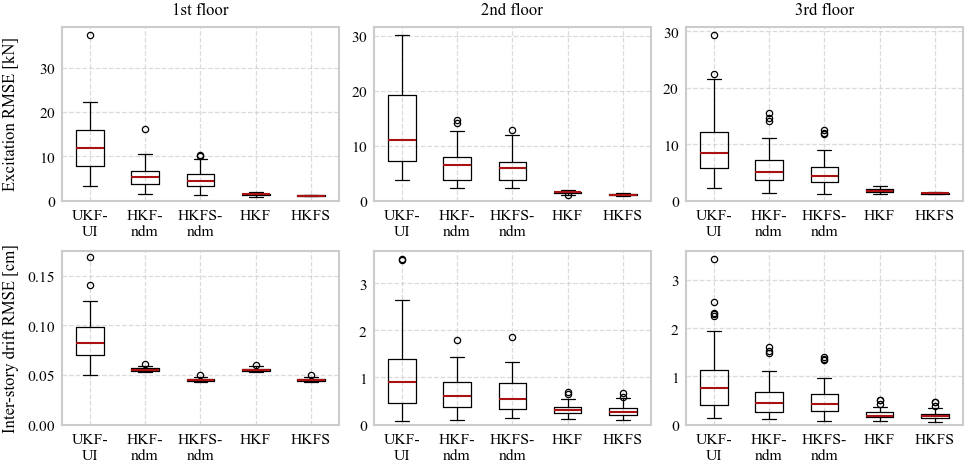

In [17]:
fig = plt.figure(figsize=(FIG_W, FIG_H*2*1.6), constrained_layout=True)

labels = ['UKF-\nUI','HKF-\nndm','HKFS-\nndm','HKF','HKFS',]
axes_row0 = []
axes_row1 = []

for f in range(system.force_dim):
    ax = fig.add_subplot(2, system.force_dim, f+1)
    axes_row0.append(ax)

    bp = ax.boxplot([(rmse_force_UKFUI/1000)[:,f], (rmse_force_HKF_ndm/1000)[:,f],
                     (rmse_force_HKFS_ndm/1000)[:,f], (rmse_force_HKF/1000)[:,f],
                     (rmse_force_HKFS/1000)[:,f]], labels=labels,
                     medianprops=dict(color=colors[2]))

    for b in bp["boxes"]:
        b.set_linewidth(0.6)
    for w in bp["whiskers"]:
        w.set_linewidth(0.6)
    for c in bp["caps"]:
        c.set_linewidth(0.6)
    for fl in bp["fliers"]:
        fl.set_markeredgewidth(0.6)
        fl.set_markersize(3)

    if f == 0:
        ax.set_ylabel('Excitation RMSE [kN]')
    ax.set_title(floors[f])
    ax.set_ylim(bottom=0)

for f in range(system.dim):
    ax = fig.add_subplot(2, system.force_dim, system.force_dim + f + 1)
    axes_row1.append(ax)

    bp = ax.boxplot([(rmse_drift_UKFUI*100)[:,f], (rmse_drift_HKF_ndm*100)[:,f],
                     (rmse_drift_HKFS_ndm*100)[:,f], (rmse_drift_HKF*100)[:,f],
                     (rmse_drift_HKFS*100)[:,f]], labels=labels,
                     medianprops=dict(color=colors[2]))

    for b in bp["boxes"]:
        b.set_linewidth(0.6)
    for w in bp["whiskers"]:
        w.set_linewidth(0.6)
    for c in bp["caps"]:
        c.set_linewidth(0.6)
    for fl in bp["fliers"]:
        fl.set_markeredgewidth(0.6)
        fl.set_markersize(3)

    if f == 0:
        ax.set_ylabel('Inter-story drift RMSE [cm]')
    ax.set_ylim(bottom=0)

fig.align_ylabels(axes_row0 + axes_row1)

outpath = os.path.join(fig_dir, f"rmse_{example_name}.pdf")
fig.savefig(outpath) 